# plotting the color grids

In [8]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import os

expFolder = "data3_grid_10Jun26"
base = Path.home() / "projects" / "metamers" / "hueSensor" / expFolder


In [39]:

def summarize_stims(path):
    df = pd.read_csv(path, sep="\t", header=0)

    # 1. Keep baseline runs
    df = df[df["Stim"] < 999]

    # 2. Keep only activation periods
    df = df[df["Trig"] == 1]

    # 3. Work only with Stim > 1
    df = df[df["Stim"] >= 1]

    # Prepare output rows
    rows = []

    # 4. Process each Stim separately
    for stim, block in df.groupby("Stim"):

        # Trim first 3 and last 3 samples
        if len(block) < 7:
            # Not enough samples to trim → skip
            continue

        trimmed = block.iloc[3:-3].reset_index(drop=True)

        # Compute means
        meanR = trimmed["HueR"].mean()
        meanG = trimmed["HueG"].mean()
        meanB = trimmed["HueB"].mean()

        # Extract 15th sample (index 14)
        if len(trimmed) > 14:
            red15 = trimmed["Red"].iloc[14]
            green15 = trimmed["Green"].iloc[14]
        else:
            red15 = None
            green15 = None

        rows.append({
            "Stim": stim,
            "meanHueR": meanR,
            "meanHueG": meanG,
            "meanHueB": meanB,
            "reds": red15,
            "greens": green15
        })

    # 5. Return as dataframe
    return pd.DataFrame(rows)

def df_to_grid(df_summary, red_values, green_values):
    Rmat = np.zeros((10, 10))
    Gmat = np.zeros((10, 10))
    Bmat = np.zeros((10, 10))

    red_values = np.array(red_values)
    green_values = np.array(green_values)

    for _, row in df_summary.iterrows():
        r = row["reds"]
        g = row["greens"]

        # Correct orientation:
        #   rows = green index
        #   cols = red index
        i = np.where(green_values == g)[0][0]   # row
        j = np.where(red_values == r)[0][0]     # column

        Rmat[i, j] = row["meanHueR"]
        Gmat[i, j] = row["meanHueG"]
        Bmat[i, j] = row["meanHueB"]

    return Rmat, Gmat, Bmat

def plot_rgb_grids(redM, greenM, Bmat, redvals, greenVals, cmap="viridis"):
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    matrices = [redM, greenM, Bmat]
    titles = ["meanHueR", "meanHueG", "meanHueB"]

    # Convert to numpy arrays
    redvals = np.array(redvals)
    greenVals = np.array(greenVals)

    # Define extent for correct axis scaling
    extent = [redvals.min(), redvals.max(), greenVals.min(), greenVals.max()]

    for ax, mat, title in zip(axes, matrices, titles):
        im = ax.imshow(
            mat,
            origin="lower",
            extent=extent,
            aspect="auto",
            cmap=cmap
        )

        ax.set_title(title)
        ax.set_xlabel("Red coordinate")
        ax.set_ylabel("Green coordinate")

        # Add colorbar
        fig.colorbar(im, ax=ax)

    plt.tight_layout()
    plt.show()


In [47]:
fileNam = base / "flash_NF.txt"
dfx = summarize_stims(fileNam)

In [50]:
print(dfx)

    Stim     meanHueR     meanHueG     meanHueB  reds  greens
0      1  1797.794872   992.205128   610.897436     0       0
1      2  1814.230769  1089.743590   648.000000     0     222
2      3  1971.769231   997.794872   629.871795   355       0
3      4  1829.948718  1274.589744   725.538462     0     444
4      5  1982.076923  1095.615385   666.358974   355     222
..   ...          ...          ...          ...   ...     ...
95    96  4282.410256  2521.923077  1465.153846  2844    1777
96    97  4645.897436  2349.974359  1422.794872  3200    1555
97    98  4292.948718  2701.358974  1538.461538  2844    2000
98    99  4618.769231  2514.820513  1488.974359  3200    1777
99   100  4607.923077  2682.282051  1556.051282  3200    2000

[100 rows x 6 columns]


In [48]:

redvals = list(set(dfx["reds"]))
redvals.sort()

greenVals = list(set(dfx["greens"]))
greenVals.sort()
print(redvals, greenVals)


redM, greenM, Bmat = df_to_grid(dfx,redvals,greenVals)


[0, 355, 711, 1066, 1422, 1777, 2133, 2488, 2844, 3200] [0, 222, 444, 666, 888, 1111, 1333, 1555, 1777, 2000]


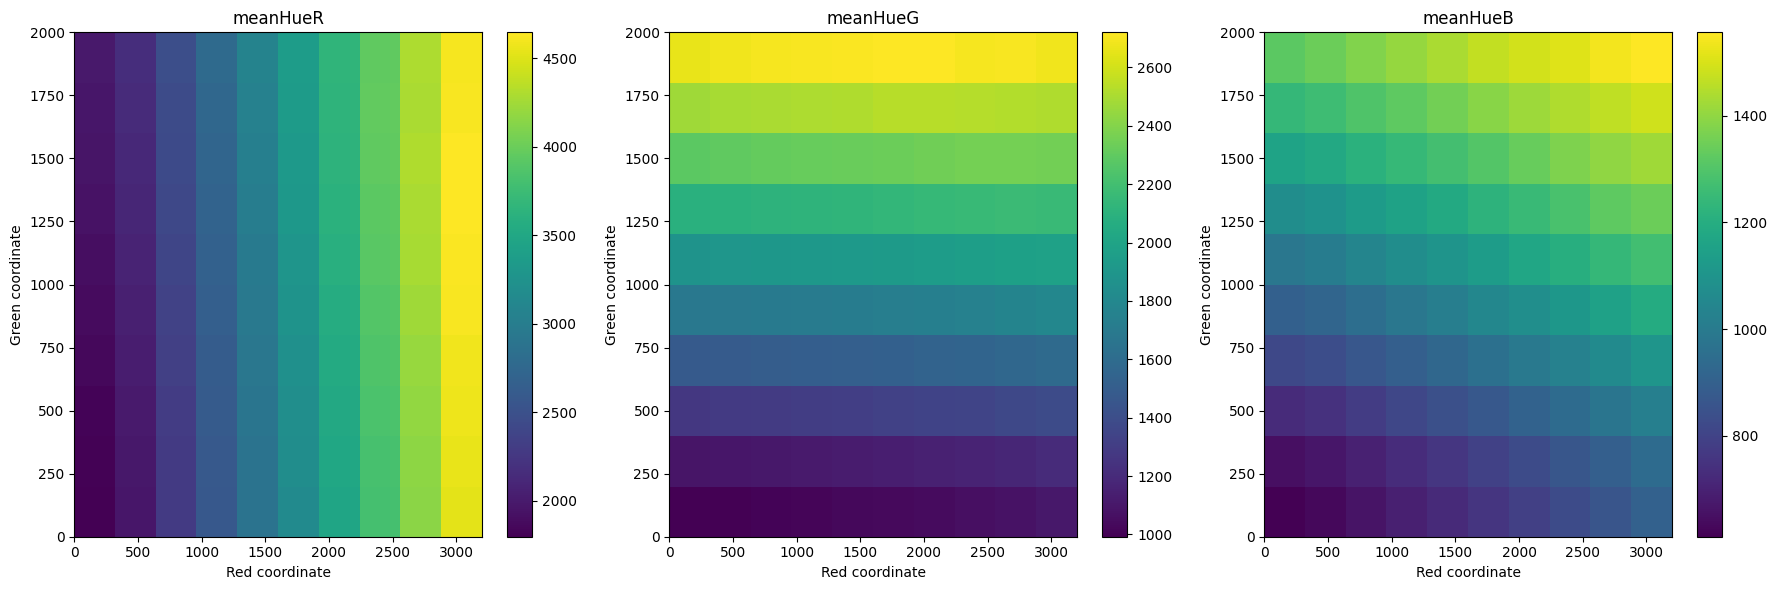

In [49]:
plot_rgb_grids(redM, greenM, Bmat, redvals, greenVals, cmap="viridis")